# DX 702 (Mod 6): Homework Reflections, 1-4

<font color='plum'> ANSWERS IN THIS COLOR

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm

from sklearn.neighbors import NearestNeighbors

random_state    = 42
testsize        = 0.2

## Homework Reflection 1

#### 1. In Coding Quiz 1, you are asked to find the distance of the farthest match in a set.  Is this farthest match distance too far to be a meaningful match? How can you decide this?


In [2]:
file_path_1 = "https://raw.githubusercontent.com/joshua-vonkorff/2025-summer-mod-6/main/homework_1.2.csv"

data = pd.read_csv(file_path_1)
data = data.drop(columns = ['Unnamed: 0'])
data.head()

,X,Y,Z
0,0,0.548814,0.548814
1,1,1.215189,0.715189
2,0,0.602763,0.602763
3,0,0.544883,0.544883
4,0,0.423655,0.423655


In [3]:

X_0 = data[data['X'] == 0]
X_1 = data[data['X'] == 1]

# Extract Z values
Z_0 = X_0[['Z']].values
Z_1 = X_1[['Z']].values
# print(f'Z_0: {Z_0}')
print(f'Z_1: {Z_1}')

Z_1: [[0.71518937]
 [0.64589411]
 [0.43758721]
 [0.891773  ]
 [0.96366276]
 [0.38344152]
 [0.79172504]
 [0.92559664]
 [0.83261985]
 [0.87001215]
 [0.97861834]
 [0.79915856]
 [0.46147936]
 [0.78052918]
 [0.63992102]
 [0.94466892]
 [0.77423369]
 [0.56843395]
 [0.6176355 ]
 [0.61209572]
 [0.94374808]
 [0.6818203 ]
 [0.3595079 ]
 [0.6976312 ]
 [0.1289263 ]
 [0.31542835]
 [0.36371077]
 [0.57019677]
 [0.43860151]
 [0.98837384]
 [0.16130952]
 [0.13818295]
 [0.19658236]
 [0.36872517]
 [0.82099323]
 [0.83794491]
 [0.97645947]
 [0.97676109]
 [0.60484552]
 [0.12019656]
 [0.2961402 ]
 [0.41426299]
 [0.69247212]
 [0.9292962 ]
 [0.66741038]
 [0.28940609]
 [0.58651293]
 [0.82894003]]


In [4]:
# Create  NearestNeighbors model, Fit on Z values of X = 0
nn = NearestNeighbors(n_neighbors = 1)
nn.fit(Z_0)

# Use NearestNeighbors to find the best match for each sample in X = 1 based on Z values
distances, indices = nn.kneighbors(Z_1)

# Get best matches
best_matches = X_0.iloc[indices.flatten()]
best_matches.head()

,X,Y,Z
93,0,0.716327,0.716327
56,0,0.653108,0.653108
41,0,0.437032,0.437032
18,0,0.778157,0.778157
18,0,0.778157,0.778157


In [5]:
# Flatten the distances array (kneighbors returns distances as a 2D array, even for n_neighbors=1)
all_distances = distances.flatten()
print(f'all_distances:\n{all_distances}\n')

distances_stats = {
    'mean_distance': np.mean(all_distances),
    'std_distance': np.std(all_distances),
    'min_distance': np.min(all_distances),
    'max_distance': np.max(all_distances),
    'median_distance': np.median(all_distances),
    'q1_distance': np.percentile(all_distances, 25),
    'q3_distance': np.percentile(all_distances, 75)
}

distances_stats

all_distances:
[0.00113784 0.00721421 0.00055526 0.11361625 0.18550601 0.03122042
 0.01356829 0.14743989 0.05446309 0.0918554  0.20046159 0.02100181
 0.00483141 0.00237243 0.0131873  0.16651217 0.00392306 0.00038939
 0.0007015  0.00483827 0.16559133 0.01118243 0.04093895 0.01869601
 0.00287156 0.00255483 0.04514182 0.00215221 0.00156956 0.21021709
 0.00233993 0.00517034 0.01229439 0.04593677 0.04283648 0.05978816
 0.19830271 0.19860434 0.00208214 0.00146884 0.01333323 0.00039895
 0.02183425 0.15113945 0.00064366 0.00659913 0.01056644 0.05078328]



{'mean_distance': 0.04978820554180685,
 'std_distance': 0.06767205572717658,
 'min_distance': 0.0003893877747161989,
 'max_distance': 0.2102170871093757,
 'median_distance': 0.013260269541804953,
 'q1_distance': 0.002509227686495405,
 'q3_distance': 0.05579436008580399}

In [6]:
farthest_distance = distances.max()
print(f"Distance of farthest match: {farthest_distance}")

Distance of farthest match: 0.2102170871093757


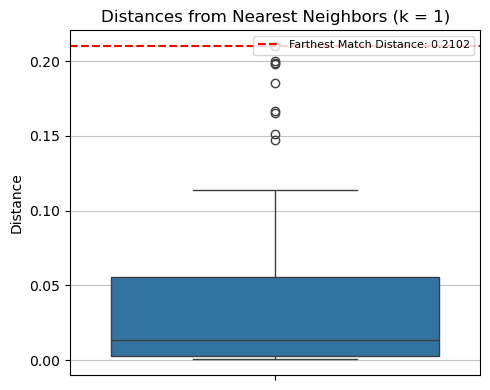

In [7]:
plt.figure(figsize=(5, 4))
sns.boxplot(y = all_distances)

# Add a horizontal line at the maximum distance
plt.axhline(y = distances_stats['max_distance'] , color='r', linestyle='--', 
            label = f'Farthest Match Distance: {distances_stats["max_distance"]:.4f}')

# Add labels and title
plt.title('Distances from Nearest Neighbors (k = 1)', fontsize = 12)
plt.ylabel('Distance', fontsize = 10)
plt.legend(fontsize = 8, loc = 'upper right')
plt.grid(axis = 'y', alpha = 0.75)

plt.tight_layout()
plt.show()

<font color='plum'>

<font color='plum'> The short answer: hard to say what 'too far' really means. But here are a few ways:

* statistical measure like z-score or t-test exceeding a threshold for statistical significance


#### 2.  In Coding Quiz 1, there are two approaches to matching: 

a.) Picking the best match X = 0 corresponding to each X = 1 using Z values.

b.) Using `radius_neighbors` to pick all matches X = 0 within a distance of 0.2 of each X = 1.

Invent your own type of matching similar to 1 and 2 (or look one up on the internet), which has a different way to pick the matches in X = 0.  Clearly explain the approach you invented or found.

#### <font color='plum'>  Mahalanobis Distance
It feels pompous to invent my own type of matching when there are already so many other matching techniques.  So, I'll talk about <u>MAHALANOBIS DISTANCE MATCHING</u> , which calculates the Mahalanobis distance, the distance between a point and a distribution of data while taking the shape of the distribution into account. The Mahalanobis distance adjusts for the:

- scale of each variable by standardizing
- correlation between variables (so redundant info isn’t double-counted).

For each treated unit, it finds the control unit(s) with the smallest Mahalanobis distance.


## Homework Reflection 2

#### 1. Invent an example situation that would use fixed effects.

<font color='plum'>
**SCENARIO 1** : Evaluating the impact of a new teaching method on student performance across multiple schools. Each school has its own unique characteristics (i.e. funding, teacher quality, student demographics) that are consistent over time but could influence student outcomes.
<br><br>
A fixed effects model could isolate the effect of the teaching method by controlling for time-invariant differences between schools; we would estimate the effect of the teaching method by comparing performance <i>within each school over time</i>, rather than <i>across</i> schools.

**SCENARIO 2**: Determining whether a 4-day workweek at Company X will increase employee productivity.

Company X could use an **individual fixed effects model** to track employee productivity over time as it switches to the 4-day schedule. By comparing employee productivity to their own baseline before the schedule change, Company X could isolate the policy's true effect, while the fixed effects control for stable, unobserved individual traits like talent or work ethic.

#### 2. Write a Python program that performs a bootstrap simulation to find the variance in the mean of the Pareto distribution when different samples are taken.  

Explain what you had to do for this.  As you make the full sample size bigger (for the same distribution), what happens to the variance of the mean of the samples?  Does it stay about the same, get smaller, or get bigger?


In [8]:
def bootstrap_variance_pareto(alpha:float, 
                              sample_size:int, 
                              num_bootstrap_samples:int
                              ) -> float: 
    """
        Returns the variance of the mean of a bunch of samples from a Pareto distribution using bootstrap resampling. 
        First, simulate a sample from a Pareto distribution with the given shape parameter,
        then perform bootstrap resampling to estimate the variance of the sample mean.
        Useful for understanding how sample size affects stability of the mean estimate.

        Parameters:
                alpha :                 Shape parameter of the Pareto distribution (must be > 0).
                sample_size :           Number of observations to draw in each sample from the Pareto distribution.
                num_bootstrap_samples : Number of bootstrap resamples to perform.

        Returns:
            Variance of the sample means of the bootstrapped samples.
    """
    # Generate sample from Pareto distribution
    sample = np.random.pareto(alpha, sample_size)
    
    # bootstrap sampling
    bootstrap_means = []
    for _ in range(num_bootstrap_samples):
        bootstrap_sample = np.random.choice(sample, size = sample_size, replace = True)
        sample_mean = bootstrap_sample.mean()
        bootstrap_means.append(sample_mean)
    
    return np.var(bootstrap_means)


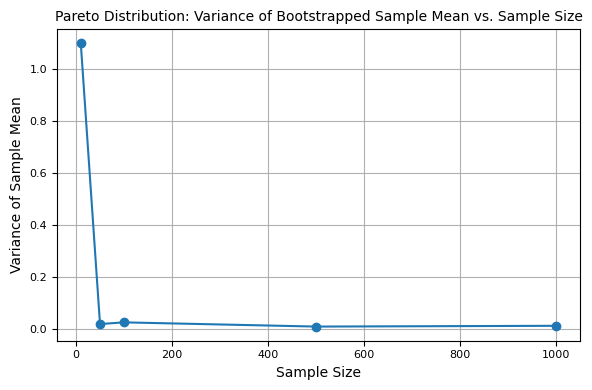

In [9]:

# Parameters
alpha           = 2.0  # Shape parameter for Pareto distribution
num_bootstrap   = 1000  # Number of bootstrap samples

sample_sizes    = [10, 50, 100, 500, 1000]

# variance for each sample size
variances       = [bootstrap_variance_pareto(alpha, size, num_bootstrap) for size in sample_sizes]

plt.figure(figsize = (6, 4))
plt.plot(sample_sizes, variances, marker='o')
plt.xlabel('Sample Size')
plt.ylabel('Variance of Sample Mean')
plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)
plt.title('Pareto Distribution: Variance of Bootstrapped Sample Mean vs. Sample Size', fontsize = 10)
plt.grid(True)
plt.tight_layout()
plt.show()

<font color='plum'>The plot shows how the variance of the sample mean changes with increasing sample size. Yours truly:
- simulated samples from a Pareto distribution, 
- bootstrapped them
- calculated  variance of the sample means.

CONCLUSION: as sample size increases, variance of the mean decreases.
(Larger samples provide more stable and accurate estimates of the population mean, reducing the variability across different samples.)


## Homework Reflection 3

#### 1. In the event study in **Coding Quiz 3**, how would we go about testing for a change in the second derivative as well?


<font color='plum'>Testing for changes in the second derivative requires adding quadratic terms to the regression model to capture acceleration over time. 
1. add squared time terms to capture the baseline curvature before the event:  `time_squared`
2. add an interaction with the event dummy to capture the change in curvature after the event: `time_squared_after_event` 

Proposed model: 
   `y = β₀ + β₁time + β₂time² + β₃event + β₄(time × event) + β₅(time² × event)`


Where:
- β₃: Captures the immediate jump (value change)
- β₄: Captures the slope change (first derivative)
- β₅: Captures the curvature change (second derivative)

If:
- β₅ > 0: trend ACCELERATES more (or decelerates less) after event
- β₅ < 0: trend DECELERATES more (or accelerates less) after event


The p-value for β₅ reveals if change in curvature is statistically significant.


#### 2. Create your own scenario that illustrates **differences-in-differences**. Describe the story behind the data and show whether there is a nonzero treatment effect.


<font color='plum'> 

##### Scenario: A New Bike-Sharing Program in my hometown

A few years ago, the city of Fremont, CA spent way too much money adding bicycle lanes that nobody asked for to major thoroughfares. Rather than encouraging more residents to use bicycles, it only made traffic worse and confused the hell out of drivers. Also, the presence of electric scooters on the sidewalks and in traffic was frustrating motorists. To nobody's surprise, the expensive bike lanes were rarely used and remain wasted empty space on otherwise busy roads. 

To encourage more bike lane usage as well as retail foot traffic in certain commercial districts, the city piloted a *public bike-sharing program* (basically, subsidized rental bikes that could be rented from kiosks) in a densely populated residential-commercial district, <u>Irvington</u>.  

A neighboring commercial-residential district, <u>Centerville</u>, which is very similar to Irvington in terms of population density, average income, and local business activity,  did not receive the bike-sharing program due to budget constraints.



##### <font color='plum'>  Hypothetical
2024 saw a city-wide economic upturn according to the tax receipts from local businesses. Customer traffic anecdotally seemed noticeably higher in both Irvington and Centerville, but did the bike-sharing program actually have a material, causal effect on the number of customers visiting local retailers in Irvington ?  A difference-in-differences analysis might explain things. (I am using hypothetical data, I really have no clue.) 

<font color='plum'>

**Treatment Group**: Retailers in the Irvington district (which piloted the bike program).


**Control Group:** Retailers in Centerville district (no bike program).


**"Before" Period**: 2023 (year prior to program launch).


**"After" Period**: 2025 (year after program launch).


**Outcome**: Average number of daily retail customers.

<font color='plum'>

**Sample Data**

District	Period	Avg. Daily Customers
Irvington (Treatment)	2023 (Before)	150
Irvington (Treatment)	2025 (After)	195


Centerville (Control)	2023 (Before)	145
Centerville (Control)	2025 (After)	160

In [10]:

data = {
    "District": ["Irvington (Treatment)", "Irvington (Treatment)", "Centerville (Control)", "Centerville (Control)"],
    "Period": ["2023 (Before)", "2025 (After)", "2023 (Before)", "2025 (After)"],
    "Avg. Daily Customers": [150, 195, 145, 160]
}

df = pd.DataFrame(data)

df['Difference']    = df.groupby('District')['Avg. Daily Customers'].diff().fillna(0)

treatment_diff      = df[df['District'] == 'Irvington (Treatment)']['Difference'].iloc[1]
control_diff        = df[df['District'] == 'Centerville (Control)']['Difference'].iloc[1]
did                 = treatment_diff - control_diff

df['DiD'] = 0
df.loc[(df['District'] == 'Irvington (Treatment)') & (df['Period'] == '2025 (After)'), 'DiD'] = did

df['Treatment Effect'] = 0
df.loc[(df['District'] == 'Irvington (Treatment)') & (df['Period'] == '2025 (After)'), 'Treatment Effect'] = did

df

,District,Period,Avg. Daily Customers,Difference,DiD,Treatment Effect
0,Irvington (Treatment),2023 (Before),150,0.0,0,0
1,Irvington (Treatment),2025 (After),195,45.0,30,30
2,Centerville (Control),2023 (Before),145,0.0,0,0
3,Centerville (Control),2025 (After),160,15.0,0,0


<font color='plum'>

**Is Treatment Effect <> 0 ?**   

To find the causal effect, I calculate the difference in the differences.

1. Customer traffic Change over time for Treatment Group (Irvington).
Change for Irvington = (Avg. Customers After) - (Avg. Customers Before) = 195 - 150 = 45 customers


2. Customer traffic Change over time for Control Group (Centerville).
Background trend, equivalently, what would have happened in Centerville due to general economic changes, even without the bike program.

    Change for Centerville = (Avg. Customers After) - (Avg. Customers Before) = 160 - 145 = 15 customers

3. Calculate Difference-in-Differences.

    Treatment Effect (DiD) = (Change for Irvington) - (Change for Centerville)  = 45 - 15 = 30 customers


**Conclusion** 

Yes, there is a nonzero treatment effect. After accounting for the general city-wide increase in retail traffic (a gain of 15 customers), I estimate that the new bike-sharing pilot (isolated from broader economic activity) caused an additional increase of 30 daily customers on average for retailers in the Treatment lcoation. 

## Homework Reflection 4

In [11]:
file_path_4_1 = "https://raw.githubusercontent.com/joshua-vonkorff/2025-summer-mod-6/main/homework_4.1.csv"

df_4_1 = pd.read_csv(file_path_4_1)
df_4_1 = df_4_1.drop(columns = ['Unnamed: 0'])
df_4_1.head()

,Z,W,X,Y
0,0,-0.155644,-0.496971,0.282484
1,1,0.529539,2.284240,4.740596
2,1,0.910514,0.872232,3.449569
3,1,-0.705476,2.157260,3.002531
4,0,-0.590874,-0.386730,-1.848796


In [12]:
file_path_4_2a = "https://raw.githubusercontent.com/joshua-vonkorff/2025-summer-mod-6/main/homework_4.2.a.csv"

df_4_2a = pd.read_csv(file_path_4_2a)
df_4_2a = df_4_2a.drop(columns = ['Unnamed: 0'])
df_4_2a.head()

# Define the cut-off score
cutoff = 0.5

# Create dummy variable and distance from cut-off
df_4_2a['above_cutoff'] = (df_4_2a['X'] >= cutoff).astype(int)
df_4_2a['dist_from_cutoff'] = df_4_2a['X'] - cutoff

In [13]:
file_path_4_2b = "https://raw.githubusercontent.com/joshua-vonkorff/2025-summer-mod-6/main/homework_4.2.b.csv"

df_4_2b = pd.read_csv(file_path_4_2b)
df_4_2b = df_4_2b.drop(columns = ['Unnamed: 0'])
df_4_2b.head()

,X2,Y2
0,76.643034,1
1,87.743397,1
2,81.639469,1
3,73.740485,0
4,90.480268,1


#### 1. The Coding Quiz gives two options for instrumental variables.  For the second method (dividing the range of W into multiple ranges):
- explain how you did it, 
- show your code, and 
- discuss any issues you encountered.


<font color='plum'>In the second method, we calculated causal effect by controlling for confounder W and then averaging the results. The idea is to estimate the effect of the treatment X on the outcome Y within narrow slices or bins of the confounder's range, where its influence is relatively constant. The process, in brief, looks like:

1. <u>Create bins for the Confounder</u>: the full range of W is divided into 10 equal-sized bins or slices. 


2. <u>Calculate "Local Effects"</u>: for each bin, calculate a "local" causal effect by taking the ratio of two differences:
- The difference in average outcome Y between subjects with instrument Z = 1 and Z = 0.
- The difference in average treatment X between subjects with instrument Z = 1 and Z = 0.


3. <u>Average the Effects</u>: The final causal effect = the average of all the "local" effects calculated in the previous step. This is a single estimate that has been adjusted for the influence of the confounder W.

In [14]:
#  Range of W
min_w = df_4_1['W'].min()
max_w = df_4_1['W'].max()

# create 10 bins for W
num_bins        = 10
bins            = np.linspace(min_w, max_w, num_bins + 1)
df_4_1['W_bin'] = pd.cut(df_4_1['W'], 
                         bins, 
                         include_lowest = True, 
                         labels = False
                         )

effect_ratios   = []

# Iterate through each W bin
for bin_label in sorted(df_4_1['W_bin'].unique()):
    df_bin = df_4_1[df_4_1['W_bin'] == bin_label]

    # Ensure there are both Z=0 and Z=1 in the bin
    if len(df_bin[df_bin['Z'] == 1]) > 0 and len(df_bin[df_bin['Z'] == 0]) > 0:
        avg_y_z1_bin = df_bin[df_bin['Z'] == 1]['Y'].mean()
        avg_y_z0_bin = df_bin[df_bin['Z'] == 0]['Y'].mean()
        
        avg_x_z1_bin = df_bin[df_bin['Z'] == 1]['X'].mean()
        avg_x_z0_bin = df_bin[df_bin['Z'] == 0]['X'].mean()

        diff_y_bin = avg_y_z1_bin - avg_y_z0_bin
        diff_x_bin = avg_x_z1_bin - avg_x_z0_bin

        # Avoid division by zero
        if diff_x_bin != 0:
            effect_ratios.append(diff_y_bin / diff_x_bin)

# Average of the ratios
effect_method_2 = np.mean(effect_ratios)

print(f"Effect using Method 2 (averaged over {num_bins} W bins): {effect_method_2:.6f}")

Effect using Method 2 (averaged over 10 W bins): 0.908542


##### <font color='plum'>
 Issues Encountered
1. Empty Bins: Local effect can't be calculated if a bin doen't have observations for both `Z = 1` or `Z = 0`. Need to check the length of the filtered dataframes and verify that both groups are present before attempting the calculation.

2.  Division by Zero: Sort of an edge case, but within a bin, it's possible for the average value of the treatment X to be the same for both Z=1 and Z=0, which makes the denominator `diff_x_bin zero`, causing an error. So, check for this condition in the loop, move on to next value when necessary. 

3.  Choice of number of bins: selecting 10 bins was a judgment call. Using too few bins may not adequately control for the confounder. Using too many bins could create small sample sizes within each bin, leading to noisy estimates and a higher chance of encountering the issues above.

#### 2. Plot the college outcome (Y) vs. the test score (X) in a small range of test scores around 80. 

On the plot, compare it with the Y probability predicted by logistic regression. The ground truth Y value is 0 or 1; don't just plot 0 or 1 - that will make it unreadable.  Find some way to make it look better than that.


<font color = 'plum'> Regression Discontinuity Design (RDD) plot. 
College outcome Y vs. test score X with overlays of the predicted probability of college admission using a logistic regression model. 


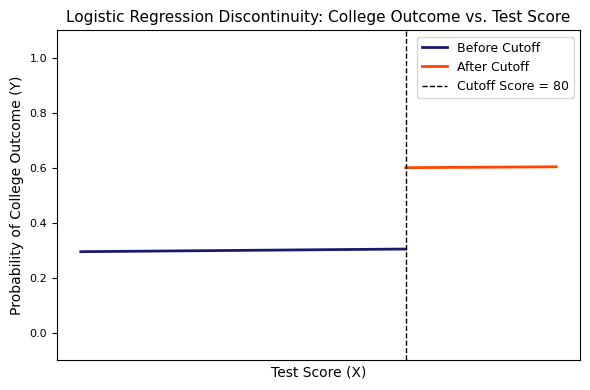

In [15]:

cutoff = 80
# --- Logistic Regression on the full dataset ---
# Split data for before and after the cutoff
df_before   = df_4_2a[df_4_2a['X'] < cutoff]
df_after    = df_4_2a[df_4_2a['X'] >= cutoff]

# Add constant for the model
X_before    = sm.add_constant(df_before['X'])
X_after     = sm.add_constant(df_after['X'])

# Fit 
model_before    = sm.Logit(df_before['Y'], X_before).fit(disp=0)
model_after     = sm.Logit(df_after['Y'], X_after).fit(disp=0)

# --- Generate Predictions ---
# Create X values for plotting the prediction lines
x_vals_before   = pd.DataFrame({'X': sorted(df_before['X'].unique())})
x_vals_after    = pd.DataFrame({'X': sorted(df_after['X'].unique())})

# Get predicted probabilities
y_preds_before  = model_before.predict(sm.add_constant(x_vals_before))
y_preds_after   = model_after.predict(sm.add_constant(x_vals_after))


fig, ax = plt.subplots(figsize=(6, 4))

# Plot raw data with jitter to make it more readable
sns.stripplot(x='X', y='Y', data = df_4_2a, ax = ax, order = [1, 0], jitter=0.05,
              color='lightgray', alpha=0.2) 

# logistic regression lines
ax.plot(x_vals_before['X'], y_preds_before, color='midnightblue', lw=2, label='Before Cutoff')
ax.plot(x_vals_after['X'], y_preds_after, color='orangered', lw=2, label='After Cutoff')

# cutoff line
ax.axvline(x=cutoff, color='black', linestyle='--', lw=1, label=f'Cutoff Score = {cutoff}')

ax.set_title('Logistic Regression Discontinuity: College Outcome vs. Test Score', fontsize=11)
ax.set_xlabel('Test Score (X)', fontsize=10)
ax.set_ylabel('Probability of College Outcome (Y)', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.legend(fontsize=9)

ax.set_ylim(-0.1, 1.1)
plt.tight_layout()
plt.show()